In [1]:
import tensorflow as tf

In [2]:
tf.__version__

'2.16.2'

I've commented out the tensorboard references, if you want to try with them, remove the comments and ensure tensorboard is installed on your machine

Will use the dataset from http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data to start

space separated and no headings so this is how can read it in

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']

df = pd.read_csv("auto-mpg.data", names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)

In [5]:
df.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


Want to build a linear regression model, to predict MPG from HorsePower, ignoring the rest

$y_{mpg} = \alpha + \beta * x_{horsepower}$

But have to clean df

In [6]:
df.isna().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [7]:
df = df.dropna()

Going to split the dataset into a set to FIT the model and to EVALUATE the model. Train/test sets

Could do this with sklearn

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(df["Horsepower"], df["MPG"], random_state=2, train_size=0.8)

In [10]:
X_train

202     95.0
184     92.0
3      150.0
176     90.0
261    120.0
       ...  
301     70.0
22      95.0
73     130.0
15      95.0
170     78.0
Name: Horsepower, Length: 313, dtype: float64

Sometimes it is useful to Normalise the data we are working with, so that the values all fall within a consistent range (if we had multiple features). Common one being StandardScaler in sklearn which makes the data have mean 0 and stddev 1

Keras has a "layer" that we can use to build this preprocessing into the model rather than doing it manually

The `preprocessing Normalization` layer is a clean and simple way to build that preprocessing into your model. You create the layer and `.adapt()` it to the data:

In [11]:
from tensorflow.keras.layers import Normalization

In [12]:
X_train.values

array([ 95.,  92., 150.,  90., 120., 115., 110.,  88., 110.,  60.,  68.,
       208.,  90., 105.,  52.,  65., 150., 225., 110., 165.,  66.,  88.,
       170.,  83.,  65., 100.,  97.,  58., 110.,  95., 103.,  88.,  65.,
       112.,  88.,  97.,  63., 170., 107.,  67., 125.,  71., 110., 198.,
        96.,  74.,  96.,  78.,  65., 105., 100.,  91.,  62.,  67.,  95.,
        86.,  68., 150., 160., 139.,  52.,  88., 130., 100.,  67.,  67.,
       180.,  86.,  90., 150., 100., 158.,  65.,  75., 113.,  75., 165.,
        71., 153.,  85.,  84.,  60., 140., 170.,  67.,  90.,  95., 150.,
       149.,  75.,  72.,  83., 220.,  98.,  71., 150.,  95.,  80.,  72.,
       150., 110.,  88., 137., 153.,  95., 102., 120.,  88.,  70., 100.,
        78.,  72.,  65., 167., 180., 170., 100., 150., 116., 105.,  75.,
        48., 110.,  90., 140.,  67., 215.,  46., 105., 198.,  71.,  75.,
        86.,  68., 145., 230.,  68., 115.,  75., 150.,  75.,  67.,  83.,
        67.,  68., 150.,  67., 150.,  84.,  63., 12

In [13]:
horsepower_normalizer = Normalization()


# use .values to convert from pd.Series to np.array

In [14]:
horsepower_normalizer.adapt(X_train.values.reshape(-1,1))

2026-03-11 00:09:56.093858: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-03-11 00:09:56.093885: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-11 00:09:56.093891: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-11 00:09:56.093908: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-11 00:09:56.093918: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [15]:
horsepower_normalizer

<Normalization name=normalization, built=True>

In [16]:
X_train.values

array([ 95.,  92., 150.,  90., 120., 115., 110.,  88., 110.,  60.,  68.,
       208.,  90., 105.,  52.,  65., 150., 225., 110., 165.,  66.,  88.,
       170.,  83.,  65., 100.,  97.,  58., 110.,  95., 103.,  88.,  65.,
       112.,  88.,  97.,  63., 170., 107.,  67., 125.,  71., 110., 198.,
        96.,  74.,  96.,  78.,  65., 105., 100.,  91.,  62.,  67.,  95.,
        86.,  68., 150., 160., 139.,  52.,  88., 130., 100.,  67.,  67.,
       180.,  86.,  90., 150., 100., 158.,  65.,  75., 113.,  75., 165.,
        71., 153.,  85.,  84.,  60., 140., 170.,  67.,  90.,  95., 150.,
       149.,  75.,  72.,  83., 220.,  98.,  71., 150.,  95.,  80.,  72.,
       150., 110.,  88., 137., 153.,  95., 102., 120.,  88.,  70., 100.,
        78.,  72.,  65., 167., 180., 170., 100., 150., 116., 105.,  75.,
        48., 110.,  90., 140.,  67., 215.,  46., 105., 198.,  71.,  75.,
        86.,  68., 145., 230.,  68., 115.,  75., 150.,  75.,  67.,  83.,
        67.,  68., 150.,  67., 150.,  84.,  63., 12

In [17]:
print('Normalized:', horsepower_normalizer(X_train.values).numpy())

Normalized: [[-0.24380238 -0.32220325  1.1935467  -0.37447047  0.4095381   0.27887
   0.1482019  -0.42673773  0.1482019  -1.158479   -0.9494101   2.7092965
  -0.37447047  0.0175338  -1.367548   -1.0278109   1.1935467   3.153568
   0.1482019   1.5855509  -1.0016773  -0.42673773  1.716219   -0.5574058
  -1.0278109  -0.11313429 -0.19153515 -1.2107463   0.1482019  -0.24380238
  -0.03473344 -0.42673773 -1.0278109   0.20046914 -0.42673773 -0.19153515
  -1.0800781   1.716219    0.06980104 -0.9755437   0.5402062  -0.87100923
   0.1482019   2.4479604  -0.21766876 -0.7926084  -0.21766876 -0.6880739
  -1.0278109   0.0175338  -0.11313429 -0.34833685 -1.1062118  -0.9755437
  -0.24380238 -0.47900495 -0.9494101   1.1935467   1.4548829   0.90607685
  -1.367548   -0.42673773  0.67087424 -0.11313429 -0.9755437  -0.9755437
   1.9775552  -0.47900495 -0.37447047  1.1935467  -0.11313429  1.4026155
  -1.0278109  -0.7664747   0.22660275 -0.7664747   1.5855509  -0.87100923
   1.2719475  -0.5051386  -0.5312722 

Now let's actually build the model. We will use Sequential, first layer to Normalise the data and second layer to actually do the $y=mx+c $

In [18]:
model = tf.keras.Sequential([
    horsepower_normalizer,
    tf.keras.layers.Dense(1)
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (313, 1)               │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (16.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3 (16.00 B)

In [19]:
model = tf.keras.Sequential()
model.add(horsepower_normalizer)
model.add(tf.keras.layers.Dense(1))

<a href="https://keras.io/api/layers/">Keras Different Types of Layers</a>

The number of inputs can either be set by the input_shape argument, or automatically when the model is run for the first time.

Dense is the layer type that will allow Linear Regression

Could also make the model as

In [20]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (313, 1)               │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (16.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3 (16.00 B)

In [21]:
model.compile(
    optimizer=tf.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error')

In [22]:
#import tensorboard
#tensorboard.__version__

In [23]:
#%reload_ext tensorboard

In [24]:
#import datetime

In [25]:
#logdir="logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
#tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [26]:
history = model.fit(
    X_train, y_train,
    epochs=40,
    verbose=1#,
    # suppress logging
    #callbacks=[tensorboard_callback]
)

Epoch 1/40


2026-03-11 00:09:56.537986: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 23.1934
Epoch 2/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 22.1779
Epoch 3/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 21.1771
Epoch 4/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 20.1819
Epoch 5/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 19.1771
Epoch 6/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 18.1763
Epoch 7/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 17.1769
Epoch 8/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 16.1776 
Epoch 9/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 15.1767
Epoch 10/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 14.1792 
Epoch 11/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 13.1828 
Epoch 12/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 12.1777 
Epoch 13/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 11.1784 
Epoch 14/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10.1851
Epoch 15/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.2149
Epoch 16/4

In [27]:
#logdir

In [28]:
#%tensorboard --logdir logs/fit --host localhost --port 8088

In [29]:
history.history

{'loss': [23.193439483642578,
  22.17792320251465,
  21.177120208740234,
  20.18193817138672,
  19.177093505859375,
  18.176332473754883,
  17.176910400390625,
  16.17760467529297,
  15.17673397064209,
  14.179203987121582,
  13.182818412780762,
  12.177675247192383,
  11.178354263305664,
  10.18508243560791,
  9.214881896972656,
  8.305989265441895,
  7.443726539611816,
  6.655450344085693,
  5.980792999267578,
  5.40304708480835,
  5.010240077972412,
  4.672544479370117,
  4.444187641143799,
  4.252658843994141,
  4.148748874664307,
  4.047967910766602,
  3.9917328357696533,
  3.9570250511169434,
  3.9222171306610107,
  3.8964250087738037,
  3.877261161804199,
  3.8679001331329346,
  3.85601544380188,
  3.8562660217285156,
  3.849332571029663,
  3.849541425704956,
  3.8493282794952393,
  3.8496077060699463,
  3.8485262393951416,
  3.8506674766540527]}

In [30]:
history.epoch

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39]

In [31]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,epoch
35,3.849541,35
36,3.849328,36
37,3.849608,37
38,3.848526,38
39,3.850667,39


In [32]:
model.evaluate(X_test, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 3.6894 


3.689373254776001

In [33]:
def plot_loss(history):
    plt.plot(history.history['loss'], label='loss')
    try:
        plt.plot(history.history['val_loss'], label='val_loss')
    except:
        None
    plt.ylim([0, 20])
    plt.xlabel('Epoch')
    plt.ylabel('Error [MPG]')
    plt.legend()
    plt.grid(True)

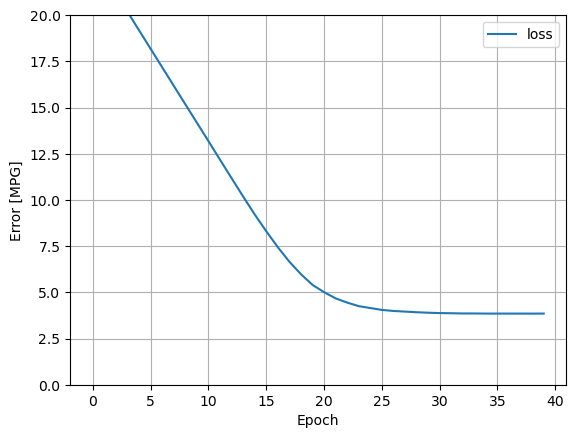

In [34]:
plot_loss(history)

In [35]:
import matplotlib.pyplot as plt

In [36]:
from sklearn.linear_model import LinearRegression

In [37]:
model_sk = LinearRegression()
model_sk.fit(X_train.values.reshape(-1,1),y_train.values)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
model_sk.coef_

array([-0.16007745])

In [39]:
model_sk.intercept_

40.31638714059322

In [40]:
print(model.predict(np.array([0])))
print(model.predict(np.array([1])))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
[[41.25228]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
[[41.080864]]


In [41]:
print(model_sk.predict(np.array([0]).reshape(-1,1)))
print(model_sk.predict(np.array([1]).reshape(-1,1)))

[40.31638714]
[40.15630969]


In [42]:
def plot_horsepower(x, y):
  plt.scatter(X_train, y_train, label='Data')
  plt.plot(x, y, color='k', label='Predictions')
  plt.xlabel('Horsepower')
  plt.ylabel('MPG')
  plt.legend()

In [43]:
#x

In [44]:
x = np.linspace(0.0, 250, 251)
y_pred = model.predict(x)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


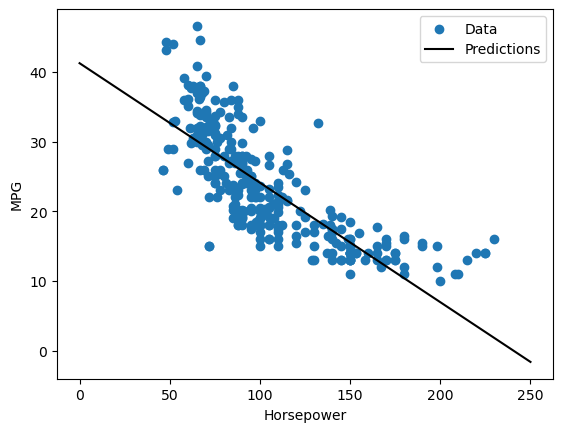

In [45]:
plot_horsepower(x,y_pred)

In [46]:
x = np.linspace(0.0, 250, 251)
y_pred = model_sk.predict(x.reshape(-1,1))

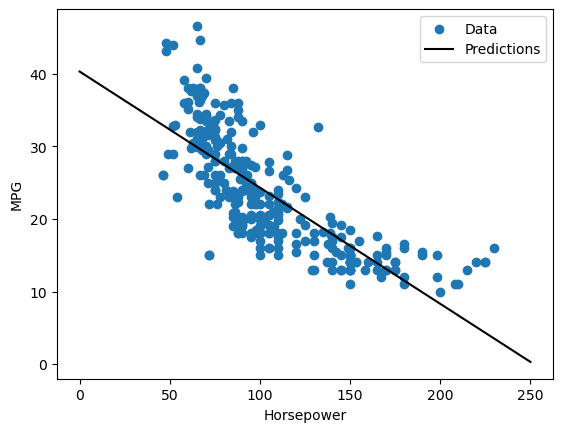

In [47]:
plot_horsepower(x,y_pred)

## Now using a Neural Network

Going to go with two hidden layers with 64 units each
The output layer will only have 1 unit (as it is a regression problem)

In [48]:
modelNN = tf.keras.Sequential([
      horsepower_normalizer,
      tf.keras.layers.Dense(64, activation='relu'),
      tf.keras.layers.Dense(64, activation='relu'),
      tf.keras.layers.Dense(1)
  ])

In [49]:
modelNN.compile(loss='mean_absolute_error',
                optimizer=tf.keras.optimizers.Adam(0.001))

In [50]:
modelNN.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (16.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3 (16.00 B)

In [51]:
#logdir="logsNN/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
#tensorboard_callbackNN = tf.keras.callbacks.TensorBoard(log_dir=logdir)

This time I've decided to use a validation set to evaluate the system at each epoch

Note that validation_split=0.2 takes the last 20% of the training data to be validation data, if I hadn't shuffled my data previously (using train_test_split) then I would need to now

In [52]:
%%time
historyNN = modelNN.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100
    #callbacks=[tensorboard_callbackNN]
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 23.6717 - val_loss: 23.0695
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 23.5576 - val_loss: 22.9507
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 23.4547 - val_loss: 22.8265
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 23.3378 - val_loss: 22.6995
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 23.2125 - val_loss: 22.5587
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 23.0753 - val_loss: 22.3965
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 22.9156 - val_loss: 22.2070
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 22.7342 - val_loss: 21.9866
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 22.5319 - val_loss: 21.7106
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 22.2621 - val_loss: 21.3986
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 21.9835 - val_loss: 21.0018
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step -

In [53]:
#%tensorboard --logdir logsNN/fit/ --host localhost --port 8088

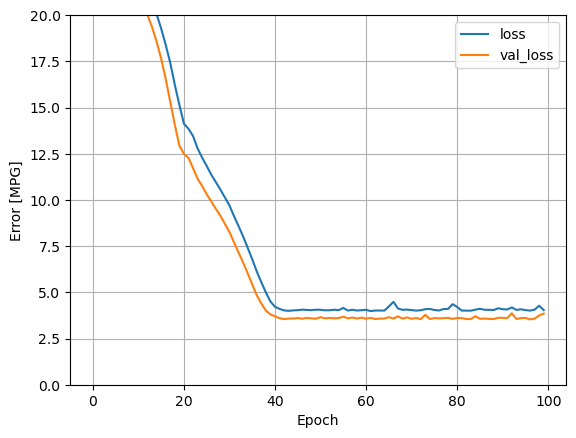

In [54]:
plot_loss(historyNN)

In [55]:
x = tf.linspace(0.0, 250, 251)
y = modelNN.predict(x)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


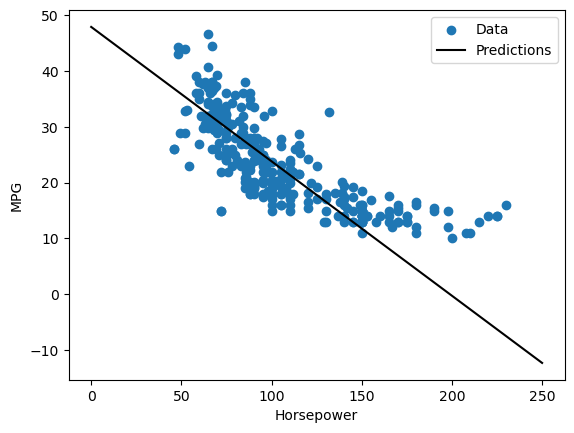

In [56]:
plot_horsepower(x,y)

Notice the different shape

In [57]:
modelNN.evaluate(X_test, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 4.5459


4.545891284942627

It's a better score